# 02 — Clima y contaminación: el cruce

Aquí se cruzan las mediciones de contaminantes con el clima horario de Open-Meteo (reanálisis ERA5) en las coordenadas de cada estación: temperatura, humedad, precipitación y viento.

La pregunta que guía el notebook: ¿por qué el invierno limeño es más contaminado? La sospecha es meteorológica — inversión térmica y poca ventilación.

In [1]:
# cargar librerias y el dataset combinado
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_parquet(RAIZ / "datos" / "procesados" / "combinado.parquet")
df["mes"] = df.fecha_hora.dt.month

# agregar a medias diarias por estacion: las relaciones clima-contaminacion
# son mas claras a escala diaria que horaria
variables = ["pm2_5", "pm10", "no2", "temperatura_c", "humedad_rel_pct", "viento_vel_kmh"]
diaria = (
    df.set_index("fecha_hora")
    .groupby("estacion")[variables]
    .resample("D")
    .mean()
    .reset_index()
)
print(f"filas horarias: {len(df):,} | filas diarias: {len(diaria):,}")

filas horarias: 577,710 | filas diarias: 24,073


## 1. Correlaciones generales (medias diarias)

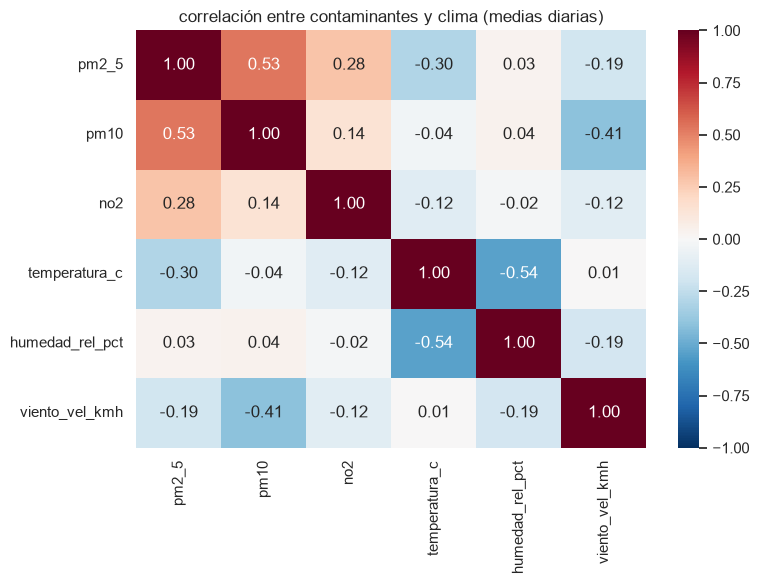

In [2]:
# calcular y graficar la matriz de correlacion de las medias diarias
correlacion = diaria[variables].corr()

fig, eje = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=eje)
eje.set_title("correlación entre contaminantes y clima (medias diarias)")
plt.tight_layout()
plt.show()

PM2.5 correlaciona negativo con temperatura (−0.30) y con viento (−0.19): los días fríos y quietos son días sucios. Las magnitudes son moderadas, y tiene sentido que lo sean: la contaminación depende sobre todo de cuánto se emite, y el clima decide cuánto se acumula.

## 2. El ciclo anual: espejo entre temperatura y PM2.5

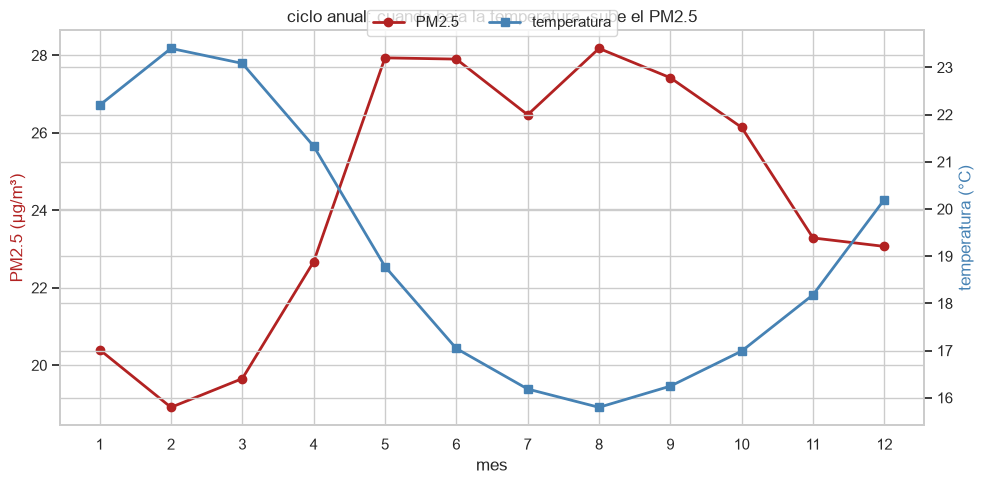

In [3]:
# graficar el ciclo anual de temperatura y pm2.5 en ejes gemelos
por_mes = df.groupby("mes")[["pm2_5", "temperatura_c"]].mean()

fig, eje1 = plt.subplots(figsize=(10, 5))
eje2 = eje1.twinx()
eje1.plot(por_mes.index, por_mes["pm2_5"], color="firebrick", marker="o", linewidth=2, label="PM2.5")
eje2.plot(por_mes.index, por_mes["temperatura_c"], color="steelblue", marker="s", linewidth=2, label="temperatura")
eje1.set_xlabel("mes")
eje1.set_ylabel("PM2.5 (µg/m³)", color="firebrick")
eje2.set_ylabel("temperatura (°C)", color="steelblue")
eje1.set_xticks(range(1, 13))
eje1.set_title("ciclo anual: cuando baja la temperatura, sube el PM2.5")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=2)
plt.tight_layout()
plt.show()

Las dos curvas van casi en espejo. En el invierno limeño (junio a septiembre) la capa de inversión térmica baja y hace de tapa: lo que se emite se concentra en menos volumen de aire. Pasa en casi todas las ciudades costeras desérticas con mar frío, y Lima es el caso de libro.

## 3. El viento como ventilador de la ciudad

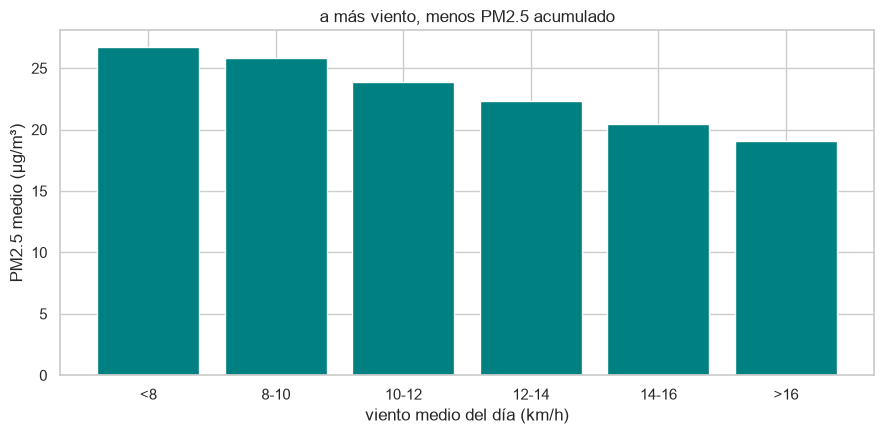

,mean,size
rango_viento,,
<8,26.7,4556
8-10,25.9,6608
10-12,23.9,6137
12-14,22.4,3644
14-16,20.5,1817
>16,19.1,1311


In [4]:
# agrupar los dias por rango de viento y calcular el pm2.5 medio de cada grupo
diaria["rango_viento"] = pd.cut(
    diaria["viento_vel_kmh"],
    bins=[0, 8, 10, 12, 14, 16, 40],
    labels=["<8", "8-10", "10-12", "12-14", "14-16", ">16"],
)
por_viento = diaria.groupby("rango_viento", observed=True)["pm2_5"].agg(["mean", "size"])

fig, eje = plt.subplots(figsize=(9, 4.5))
eje.bar(por_viento.index.astype(str), por_viento["mean"], color="teal")
eje.set_xlabel("viento medio del día (km/h)")
eje.set_ylabel("PM2.5 medio (µg/m³)")
eje.set_title("a más viento, menos PM2.5 acumulado")
plt.tight_layout()
plt.show()
por_viento.round(1)

La relación es consistente: los días con viento medio por debajo de 8 km/h acumulan bastante más PM2.5 que los que pasan de 16. El viento no elimina nada, solo lo reparte.

## 4. Invierno vs verano, estación por estación

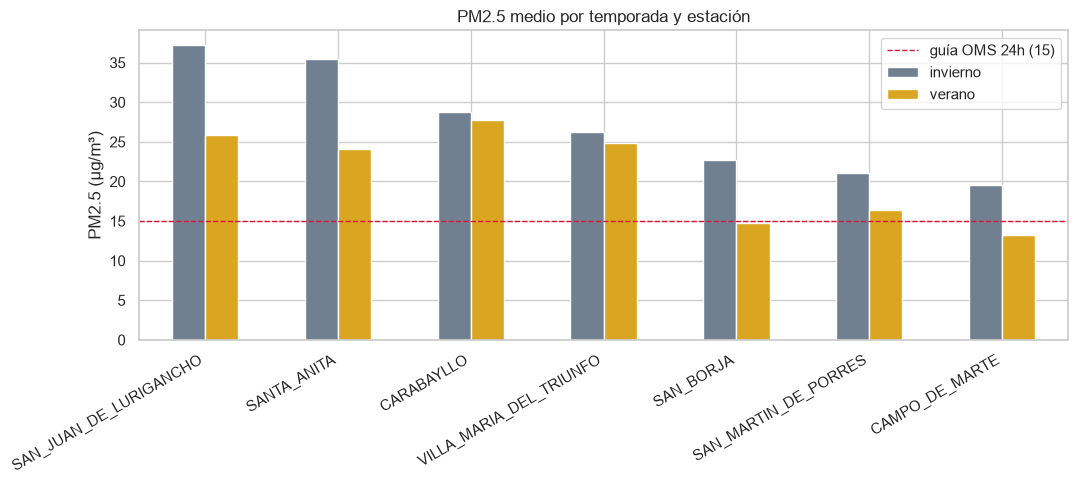

estacion
SAN_JUAN_DE_LURIGANCHO     1.44
SANTA_ANITA                1.47
CARABAYLLO                 1.04
VILLA_MARIA_DEL_TRIUNFO    1.06
SAN_BORJA                  1.53
SAN_MARTIN_DE_PORRES       1.29
CAMPO_DE_MARTE             1.48
Name: ratio invierno/verano, dtype: float64

In [5]:
# comparar pm2.5 de invierno y verano en cada estacion
df["temporada"] = df["mes"].map(
    {12: "verano", 1: "verano", 2: "verano", 6: "invierno", 7: "invierno", 8: "invierno"}
)
tabla = (
    df[df["temporada"].notna()]
    .groupby(["estacion", "temporada"])["pm2_5"]
    .mean()
    .unstack()
    .sort_values("invierno", ascending=False)
)

fig, eje = plt.subplots(figsize=(11, 5))
tabla.plot.bar(ax=eje, color={"invierno": "slategray", "verano": "goldenrod"})
eje.set_ylabel("PM2.5 (µg/m³)")
eje.set_xlabel("")
eje.set_title("PM2.5 medio por temporada y estación")
eje.axhline(15, color="crimson", linestyle="--", linewidth=1, label="guía OMS 24h (15)")
eje.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
(tabla["invierno"] / tabla["verano"]).round(2).rename("ratio invierno/verano")

El castigo del invierno no es parejo. Las estaciones del este (San Juan de Lurigancho, Santa Anita) y del sur (Villa María del Triunfo) dan los mayores saltos invernales; en las céntricas y costeras el efecto es menor porque la brisa marina las ventila mejor.

## Hallazgos

El clima explica el calendario de la contaminación. PM2.5 correlaciona negativo con temperatura y viento a escala diaria, y su ciclo anual es casi el espejo invertido del de temperatura.

El mecanismo es la ventilación, no las emisiones. En invierno no se emite más: el aire frío y quieto, con la inversión térmica encima, atrapa lo que siempre se emite. Los días con poco viento acumulan mucho más PM2.5 que los ventosos.

La geografía importa. Los distritos del este y del interior sufren el invierno bastante más que los costeros. La desigualdad ambiental que apareció en el notebook 01 tiene una base meteorológica, no solo de emisiones.